In [1]:
import json
import pandas as pd

from movement.io import load_pose_csv, print_data_summary
from movement.config import (
    LANDMARKS,
    CONNECTIONS,
    make_required_columns,
    make_coordinate_columns,
    make_visibility_columns,
)
from movement.validation import run_basic_validation
from movement.visualization import create_pose_animation

In [2]:
csv_path = "../data/mediapipe_forward_bend_sample.csv"

df = load_pose_csv(csv_path)
print_data_summary(df)

df.head()

Data shape: (120, 134)
Frame range: 0 to 119
Timestamp range: 0.0 to 3.966667


,frame,timestamp,nose_x,nose_y,nose_z,nose_visibility,left_eye_inner_x,left_eye_inner_y,left_eye_inner_z,left_eye_inner_visibility,...,right_heel_z,right_heel_visibility,left_foot_index_x,left_foot_index_y,left_foot_index_z,left_foot_index_visibility,right_foot_index_x,right_foot_index_y,right_foot_index_z,right_foot_index_visibility
0,0,0.000000,0.500000,0.220000,0.030000,0.98,0.482000,0.195000,0.030000,0.98,...,0.000000,0.98,0.420000,0.98,0.090000,0.98,0.580000,0.98,0.090000,0.98
1,1,0.033333,0.500290,0.220209,0.030503,0.98,0.482290,0.195209,0.030503,0.98,...,0.000169,0.98,0.420290,0.98,0.090169,0.98,0.580290,0.98,0.090169,0.98
2,2,0.066667,0.500579,0.220836,0.031674,0.98,0.482579,0.195836,0.031674,0.98,...,0.000338,0.98,0.420579,0.98,0.090338,0.98,0.580579,0.98,0.090338,0.98
3,3,0.100000,0.500867,0.221878,0.033510,0.98,0.482867,0.196878,0.033510,0.98,...,0.000506,0.98,0.420867,0.98,0.090506,0.98,0.580867,0.98,0.090506,0.98
4,4,0.133333,0.501151,0.223333,0.036005,0.98,0.483151,0.198333,0.036005,0.98,...,0.000673,0.98,0.421151,0.98,0.090673,0.98,0.581151,0.98,0.090673,0.98


In [3]:
report = run_basic_validation(
    df=df,
    required_columns=make_required_columns(),
    coordinate_columns=make_coordinate_columns(),
    visibility_columns=make_visibility_columns(),
)

report["passed"]

True

In [4]:
summary = {
    "passed": report["passed"],
    "required_columns": report["required_columns"]["passed"],
    "frame_continuity": report["frame_continuity"]["passed"],
    "timestamp": report["timestamp"]["passed"],
    "missing_values": report["missing_values"]["passed"],
    "visibility": report.get("visibility", {}).get("passed", None),
    "estimated_fps": report["timestamp"].get("estimated_fps"),
    "num_rows": report["frame_continuity"].get("num_rows"),
    "num_missing_frames": report["frame_continuity"].get("num_missing_frames"),
    "num_duplicated_frames": report["frame_continuity"].get("num_duplicated_frames"),
}

summary

{'passed': True,
 'required_columns': True,
 'frame_continuity': True,
 'timestamp': True,
 'missing_values': True,
 'visibility': True,
 'estimated_fps': 30.00030000299998,
 'num_rows': None,
 'num_missing_frames': 0,
 'num_duplicated_frames': 0}

In [5]:
failed_sections = {
    name: section
    for name, section in report.items()
    if isinstance(section, dict) and section.get("passed") is False
}

failed_sections

{}

In [6]:
print(json.dumps(report, indent=2, ensure_ascii=False))

{
  "required_columns": {
    "passed": true,
    "missing_columns": [],
    "num_missing_columns": 0
  },
  "frame_continuity": {
    "passed": true,
    "start_frame": 0,
    "end_frame": 119,
    "num_frames": 120,
    "num_missing_frames": 0,
    "missing_frames": [],
    "num_duplicated_frames": 0,
    "duplicated_frames": []
  },
  "timestamp": {
    "passed": true,
    "num_timestamps": 120,
    "median_dt": 0.03333300000000006,
    "estimated_fps": 30.00030000299998,
    "min_dt": 0.033332999999999835,
    "max_dt": 0.033334000000000086,
    "num_non_positive_diffs": 0
  },
  "missing_values": {
    "passed": true,
    "num_columns": 99,
    "total_missing_values": 0,
    "missing_ratio_by_column": {
      "nose_x": 0.0,
      "nose_y": 0.0,
      "nose_z": 0.0,
      "left_eye_inner_x": 0.0,
      "left_eye_inner_y": 0.0,
      "left_eye_inner_z": 0.0,
      "left_eye_x": 0.0,
      "left_eye_y": 0.0,
      "left_eye_z": 0.0,
      "left_eye_outer_x": 0.0,
      "left_eye_oute

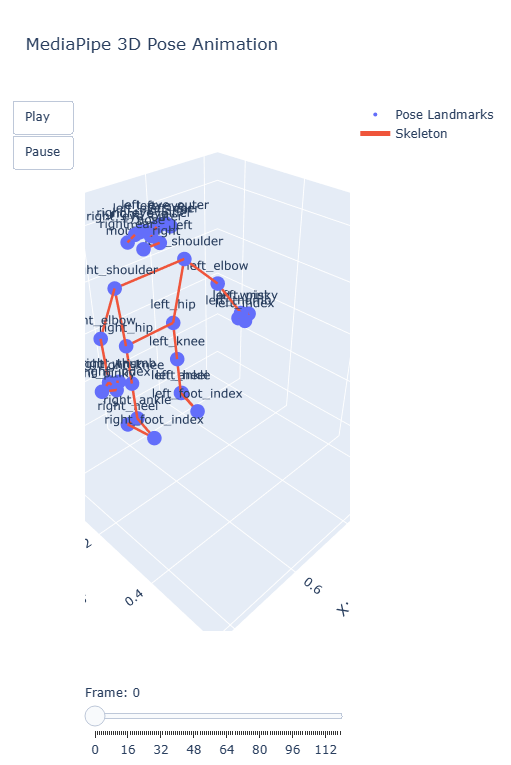

In [7]:
fig = create_pose_animation(
    df=df,
    landmarks=LANDMARKS,
    connections=CONNECTIONS,
)

fig.show()